In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/ckay16
/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage
/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage/data
/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage/data/val
/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage/data/val/Non Accident
/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage/data/val/Accident
/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage/data/test
/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage/data/test/Non Accident
/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage/data/test/Accident
/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage/data/train
/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage/data/train/Non Accident
/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage/data/train/Accident


In [2]:
import os

base_path = "/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage/data"

for split in ["train", "test", "val"]:
    print(f"\n{split.upper()}")
    
    split_path = os.path.join(base_path, split)
    
    for cls in os.listdir(split_path):
        class_path = os.path.join(split_path, cls)
        
        if os.path.isdir(class_path):
            print(f"{cls}: {len(os.listdir(class_path))} images")


TRAIN
Non Accident: 422 images
Accident: 369 images

TEST
Non Accident: 54 images
Accident: 47 images

VAL
Non Accident: 52 images
Accident: 46 images


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage/data/train"
val_dir = "/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage/data/val"
test_dir = "/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage/data/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

2026-06-07 17:11:09.751706: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780852269.978298      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780852270.045433      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780852270.613150      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780852270.613200      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780852270.613203      16 computation_placer.cc:177] computation placer alr

Found 791 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-07 17:11:29.026570: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.5398 - loss: 0.7687 - val_accuracy: 0.5306 - val_loss: 0.6898
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.5348 - loss: 0.6908 - val_accuracy: 0.5918 - val_loss: 0.6834
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.5626 - loss: 0.6915 - val_accuracy: 0.5714 - val_loss: 0.6814
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.5689 - loss: 0.6879 - val_accuracy: 0.5612 - val_loss: 0.6632
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.5651 - loss: 0.6937 - val_accuracy: 0.5510 - val_loss: 0.6797
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.5777 - loss: 0.6840 - val_accuracy: 0.6020 - val_loss: 0.6627
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.5803 - loss: 0.6739 - val_accuracy: 0.6122 - val_loss: 0.6253
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.6005 - loss: 0.6723 - val_accuracy: 0.5408 - val_loss:

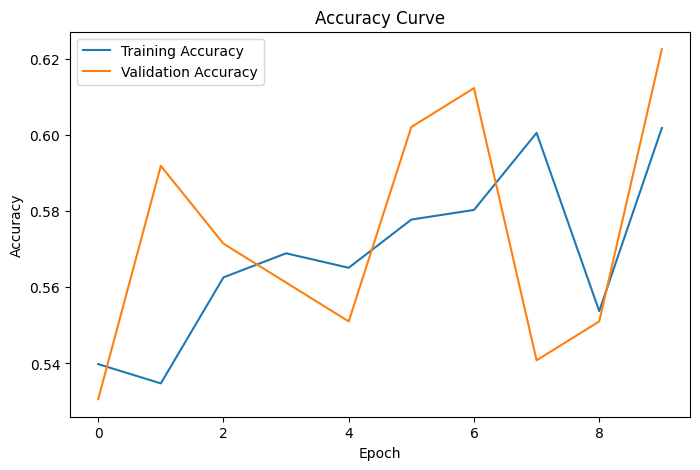

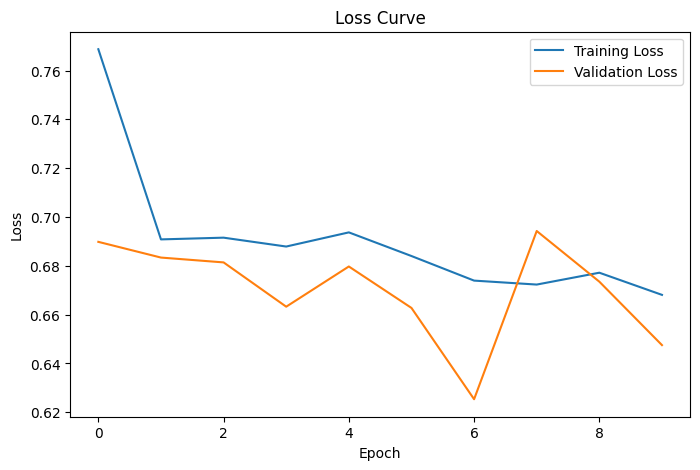

In [6]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [7]:
test_loss, test_acc = cnn_model.evaluate(test_generator)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 463ms/step - accuracy: 0.6300 - loss: 0.6469
Test Accuracy: 0.6299999952316284
Test Loss: 0.6468665599822998


In [8]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

predictions = cnn_model.predict(test_generator)

y_pred = (predictions > 0.5).astype(int)

cm = confusion_matrix(test_generator.classes, y_pred)

print("Confusion Matrix")
print(cm)

print("\nClassification Report")
print(classification_report(
    test_generator.classes,
    y_pred,
    target_names=test_generator.class_indices.keys()
))

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 436ms/step
Confusion Matrix
[[17 30]
 [ 7 46]]

Classification Report
              precision    recall  f1-score   support

    Accident       0.71      0.36      0.48        47
Non Accident       0.61      0.87      0.71        53

    accuracy                           0.63       100
   macro avg       0.66      0.61      0.60       100
weighted avg       0.65      0.63      0.60       100



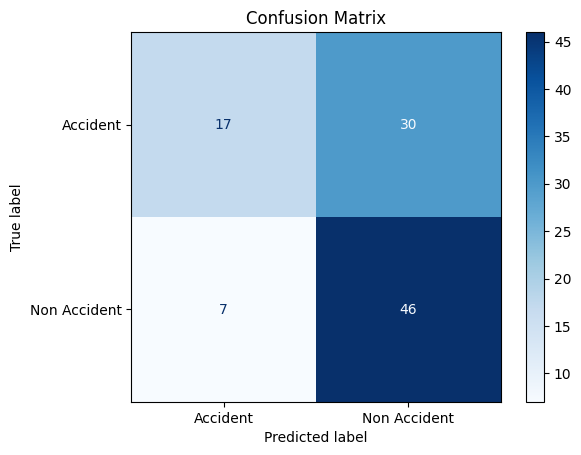

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_generator.class_indices.keys()
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [10]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(1, activation='sigmoid')(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5209 - loss: 0.8381 - val_accuracy: 0.5714 - val_loss: 0.7028
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.5967 - loss: 0.7256 - val_accuracy: 0.6224 - val_loss: 0.6555
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.6056 - loss: 0.6902 - val_accuracy: 0.6429 - val_loss: 0.6033
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.6485 - loss: 0.6330 - val_accuracy: 0.6633 - val_loss: 0.6070
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6271 - loss: 0.6416 - val_accuracy: 0.6735 - val_loss: 0.5666


In [12]:
mobilenet_loss, mobilenet_acc = mobilenet_model.evaluate(test_generator)

print("MobileNetV2 Test Accuracy:", mobilenet_acc)
print("MobileNetV2 Test Loss:", mobilenet_loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 524ms/step - accuracy: 0.7000 - loss: 0.6076
MobileNetV2 Test Accuracy: 0.699999988079071
MobileNetV2 Test Loss: 0.6075528860092163


In [13]:
plt.savefig("accuracy_curve.png")
plt.savefig("loss_curve.png")
plt.savefig("confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [14]:
print("Train:", train_generator.class_indices)
print("Val:", val_generator.class_indices)
print("Test:", test_generator.class_indices)

Train: {'Accident': 0, 'Non Accident': 1}
Val: {'Accident': 0, 'Non Accident': 1}
Test: {'Accident': 0, 'Non Accident': 1}


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction Score: 0.17355177
🚨 Accident


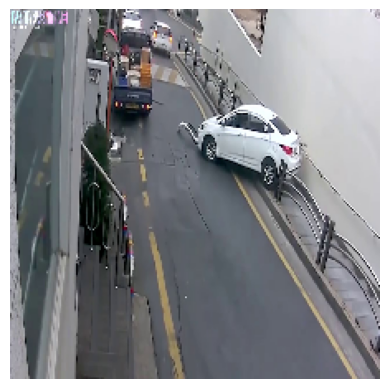

In [15]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = "/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage/data/test/Accident/test10_33.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = mobilenet_model.predict(img_array)[0][0]

print("Prediction Score:", prediction)


if prediction > 0.5:
    print("✅ Non Accident")
else:
    print("🚨 Accident")

plt.imshow(img)
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Prediction Score: 0.5151269
✅ Non Accident


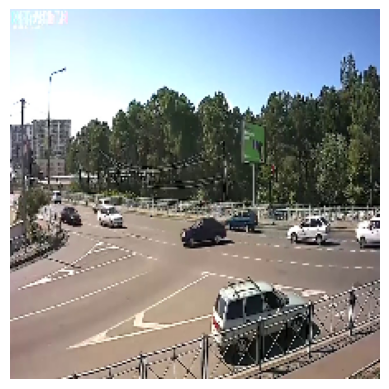

In [16]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = "/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage/data/test/Non Accident/test11_12.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = mobilenet_model.predict(img_array)[0][0]

print("Prediction Score:", prediction)


if prediction > 0.5:
    print("✅ Non Accident")
else:
    print("🚨 Accident")

plt.imshow(img)
plt.axis("off")
plt.show()